# TorchRL_MAC Training Example

End-to-end CTDE A3C training on MPE `simple_spread` with visualization.

This notebook:
1. Configures environment and training hyperparameters
2. Trains a multi-agent system using centralized critic with asynchronous parallel workers
3. Plots learning curves
4. Evaluates with greedy actions

## 1. Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from TorchRL_MAC_utils import (
    EnvConfig,
    TrainConfig,
    train_ctde_a3c,
    make_env,
    build_shared_actor,
    build_central_critic,
    get_device,
)

print(f"PyTorch version: {torch.__version__}")
print(f"Available device: {get_device()}")

PyTorch version: 2.7.0
Available device: mps


## 2. Configuration

Set up environment and training hyperparameters. Using moderate episode count for quick demonstration.

New A3C-specific parameters:
- `n_workers`: Number of parallel asynchronous workers
- `t_max`: Maximum steps per worker update
- `device`: Set to `None` for auto-detect (MPS on Mac, CPU otherwise)

In [2]:
# Environment configuration
env_cfg = EnvConfig(
    env_name="simple_spread",
    max_steps=100,
    device="cpu"  # MPS for single-process, CPU for A3C workers
)

# Training configuration for A3C
train_cfg = TrainConfig(
    gamma=0.99,
    lr_actor=1e-4,
    lr_critic=3e-4,
    entropy_coef=0.005,
    value_coef=0.5,
    max_grad_norm=0.5,
    log_every=25,     
    device="cpu",  # MPS default, but A3C workers use CPU
    # A3C-specific parameters
    num_workers=4,  # Number of parallel workers
    n_steps=75,  # Rollout length per update
    max_episodes=5000,  # Stop after 300 episodes
    sync_every=1,  # Sync weights every episode
)

print(f"Environment config: {env_cfg}")
print(f"\nTraining config: {train_cfg}")

Environment config: EnvConfig(env_name='simple_spread', seed=0, max_steps=100, device='cpu')

Training config: TrainConfig(gamma=0.99, lr_actor=0.0001, lr_critic=0.0003, entropy_coef=0.005, value_coef=0.5, max_grad_norm=0.5, n_episodes=500, log_every=25, device='cpu', debug_grads=False, num_workers=4, n_steps=75, max_episodes=5000, sync_every=1, seed=0)


## 3. Train CTDE A3C

Run the complete A3C training loop with asynchronous parallel workers.

**Note:** A3C uses CPU workers for stability; MPS is default for single-process modes.

In [3]:
print("Starting A3C training...")
history = train_ctde_a3c(env_cfg, train_cfg)
print(f"\nTraining complete! Final episode return: {history['episode_return'][-1]:.2f}")

Starting A3C training...
[A3C] Using CPU for 4 workers (MPS doesn't support multiprocessing)


/opt/anaconda3/envs/ds_mode/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/opt/anaconda3/envs/ds_mode/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/opt/anaconda3/envs/ds_mode/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for remo

[Entropy Check] Initial entropy: 1.6057 (expected ~ln(5)=1.6090)
... | Actor μ/σ: +2.926e-04/6.771e-02 | Critic μ/σ: +1.048e-03/6.071e-02
Episode  25/5000 | Avg Return:  -138.36 | Entropy: 1.6051 (increasing)
... | Actor μ/σ: +3.081e-04/6.771e-02 | Critic μ/σ: +3.823e-03/6.184e-02
Episode  50/5000 | Avg Return:  -148.22 | Entropy: 1.6045 (increasing)
... | Actor μ/σ: +3.340e-04/6.771e-02 | Critic μ/σ: +7.174e-03/6.357e-02
Episode  76/5000 | Avg Return:  -145.12 | Entropy: 1.6054 (increasing)
... | Actor μ/σ: +3.434e-04/6.772e-02 | Critic μ/σ: +1.027e-02/6.539e-02
Episode 102/5000 | Avg Return:  -134.32 | Entropy: 1.6050 (decreasing)
... | Actor μ/σ: +4.067e-04/6.773e-02 | Critic μ/σ: +1.228e-02/6.674e-02
Episode 127/5000 | Avg Return:  -126.28 | Entropy: 1.6034 (decreasing)
... | Actor μ/σ: +3.966e-04/6.773e-02 | Critic μ/σ: +1.354e-02/6.758e-02
Episode 152/5000 | Avg Return:  -134.16 | Entropy: 1.6006 (increasing)
... | Actor μ/σ: +3.685e-04/6.772e-02 | Critic μ/σ: +1.437e-02/6.827e-0

## 4. Plot Learning Curves

Visualize training progress across episodes.

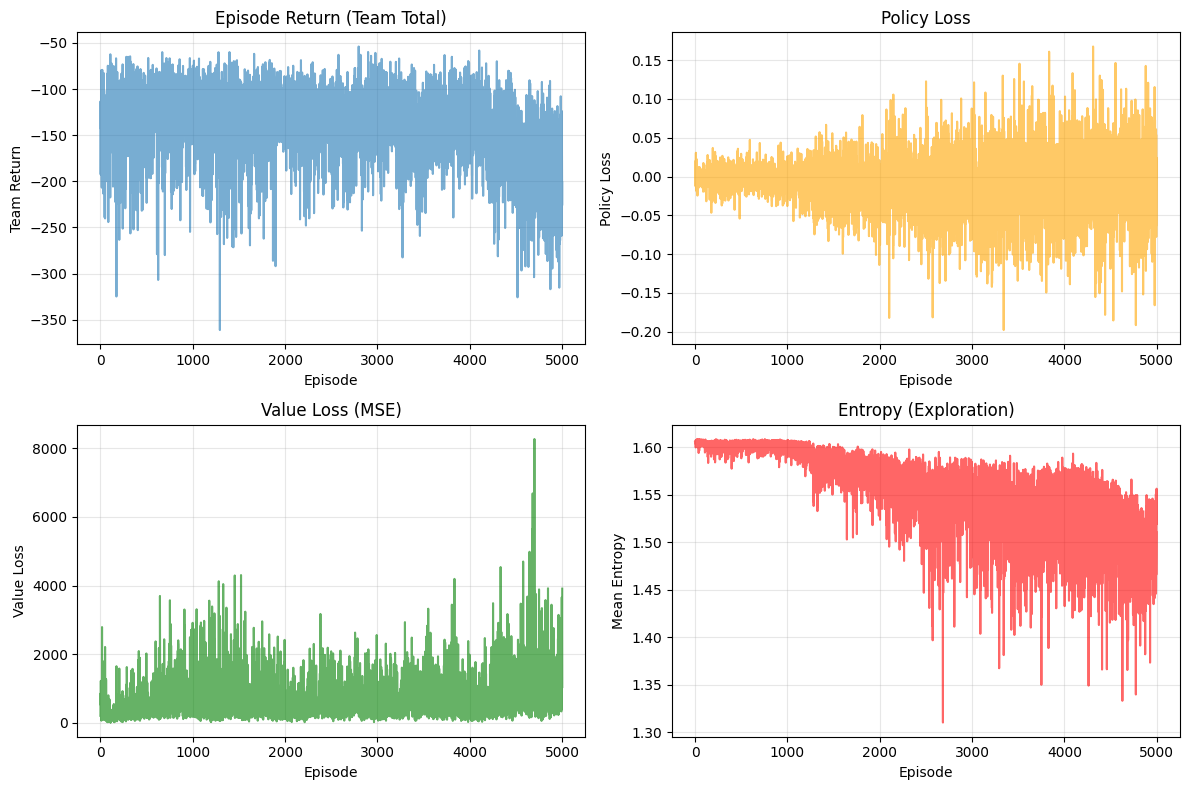

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Episode return
axes[0, 0].plot(history["episode_return"], alpha=0.6)
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Team Return")
axes[0, 0].set_title("Episode Return (Team Total)")
axes[0, 0].grid(True, alpha=0.3)

# Policy loss
axes[0, 1].plot(history["policy_loss"], alpha=0.6, color="orange")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Policy Loss")
axes[0, 1].set_title("Policy Loss")
axes[0, 1].grid(True, alpha=0.3)

# Value loss
axes[1, 0].plot(history["value_loss"], alpha=0.6, color="green")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Value Loss")
axes[1, 0].set_title("Value Loss (MSE)")
axes[1, 0].grid(True, alpha=0.3)

# Entropy
axes[1, 1].plot(history["entropy"], alpha=0.6, color="red")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Mean Entropy")
axes[1, 1].set_title("Entropy (Exploration)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Greedy Evaluation (Optional)

Run one episode with deterministic (argmax) actions to evaluate learned policy performance.

In [12]:
# Rebuild actor from trained weights (in real scenario, save/load checkpoints)
# For this demo, we'll retrain quickly or note that actor is lost after function returns
# To properly evaluate, we'd need to return actor/critic from train_ctde_a2c

# Workaround: Re-instantiate and note this is just a demonstration pattern
# In production, modify train_ctde_a2c to return (history, actor, critic)

eval_env = make_env(env_cfg)
obs = eval_env.reset(seed=999)  # Different seed for evaluation
n_agents, obs_dim = obs.shape

# Build fresh actor (untrained for demo purposes - see note above)
eval_actor = build_shared_actor(obs_dim, eval_env.n_actions)

print("Note: For proper evaluation, save actor/critic during training.")
print("This cell demonstrates the evaluation pattern with a fresh (untrained) actor.")
print("To get trained weights, modify train_ctde_a2c to return models.\n")

done = False
total_reward = 0.0
step_count = 0

with torch.no_grad():
    while not done and step_count < env_cfg.max_steps:
        logits = eval_actor(obs)
        actions = logits.argmax(dim=-1)  # Greedy (deterministic)
        obs, rewards, done = eval_env.step(actions)
        total_reward += rewards.mean().item()
        step_count += 1

print(f"Greedy evaluation return: {total_reward:.2f} (over {step_count} steps)")
print("(Untrained baseline; trained model would show higher return)")

eval_env.env.close()

Note: For proper evaluation, save actor/critic during training.
This cell demonstrates the evaluation pattern with a fresh (untrained) actor.
To get trained weights, modify train_ctde_a2c to return models.

Greedy evaluation return: -14.57 (over 25 steps)
(Untrained baseline; trained model would show higher return)


## Summary

**What we demonstrated:**
- End-to-end CTDE A3C training on MPE `simple_spread` with asynchronous parallel workers
- Proper multiprocessing with CPU workers (MPS doesn't support shared memory)
- Training history tracking (returns, losses, entropy)
- Visualization of learning progress across multiple workers

**Key observations:**
- Episode return should increase over training
- Entropy should decrease (more confident policies)
- Value loss stabilizes as critic learns return distribution
- A3C parallel workers provide diverse exploration and faster convergence

**A3C Architecture:**
- **Global networks**: Shared actor and critic on CPU with `.share_memory()`
- **Worker processes**: Each worker has local network copies, collects n-step rollouts
- **Asynchronous updates**: Workers compute gradients locally, update global networks under lock
- **Periodic sync**: Workers sync local weights from global periodically

**Why CPU for A3C workers:**
- MPS (Apple GPU) doesn't support multiprocessing shared memory
- Global networks on CPU can be safely shared across processes
- Training still benefits from parallelism via multiple CPU cores

**Next steps:**
1. Increase `max_episodes` to 500+ for better convergence
2. Tune `num_workers` based on your CPU cores (4-8 typical)
3. Adjust `n_steps` (rollout length) for different exploration/exploitation trade-offs
4. Experiment with hyperparameters (learning rates, entropy coefficient)
5. Try other MPE scenarios (`simple_reference`, `simple_adversary`)
6. Save/load trained models for evaluation